# Phase 3 - AI 데이터센터 입지 및 ESS 최적화

실행 순서

1. 입력자료 및 상수 설정
2. 건설 가능한 직사각형 후보지 생성
3. 풍력 잉여전력 프로파일 생성
4. Stage 1 Gurobi 입지선정
5. Stage 2 Gurobi ESS 용량 산정
6. 전체 규모 조합 비교 및 최종안 선정
7. 최종 부지 검증·시각화
8. ESS 예산 증설 시뮬레이션

`population`은 실제 인원수가 아닌 상대 밀도지표로 해석한다. 후보지별 합계 대신 평균을 사용하고, 같은 규모 후보 안에서 백분위 점수로 정규화해 부지선정에 반영한다.


In [2]:
from __future__ import annotations

from collections import defaultdict
from pathlib import Path
import math

import gurobipy as gp
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gurobipy import GRB

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj.to_string() if hasattr(obj, "to_string") else obj)

for font_path in (
    Path("C:/Windows/Fonts/malgun.ttf"),
    Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"),
    Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf"),
):
    if font_path.exists():
        fm.fontManager.addfont(font_path)
        plt.rcParams["font.family"] = fm.FontProperties(
            fname=font_path
        ).get_name()
        break
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)


def find_input(pattern: str) -> Path:
    for directory in (Path.cwd(), Path.cwd() / "upload"):
        matches = sorted(directory.glob(pattern))
        if matches:
            return matches[0]
    raise FileNotFoundError(
        f"입력 파일을 찾지 못했습니다: {pattern}"
    )


def read_csv_with_fallback(path: Path) -> pd.DataFrame:
    for encoding in ("utf-8-sig", "cp949", "utf-8"):
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"CSV 인코딩을 확인해 주세요: {path}")


grid = read_csv_with_fallback(find_input("terrain_grid_100m*.csv"))
locations = read_csv_with_fallback(
    find_input("substation_locations.csv")
)
boundary = read_csv_with_fallback(
    find_input("gyeongju_boundary.csv")
)
prediction = read_csv_with_fallback(
    find_input("Phase2_Task2_평가셋예측.csv")
)

substations = locations.loc[
    locations["type"].eq("substation")
].copy()
if len(substations) != 3:
    raise ValueError(
        f"변전소는 3개여야 합니다. 현재 {len(substations)}개입니다."
    )

# ------------------------------ 문제에 주어진 상수
CELL_HALF_DIAGONAL_KM = math.sqrt(50**2 + 50**2) / 1000
SAFE_SUBSTATION_DISTANCE_KM = 2.0 + CELL_HALF_DIAGONAL_KM

SITE_SHAPES = {
    30: [(3, 3), (2, 5), (5, 2)],
    50: [(4, 4), (3, 6), (6, 3), (2, 8), (8, 2)],
}
BUILD_COST = {30: 30_000.0, 50: 40_000.0}
SUB_IMPORT_MW = {30: 30.0, 50: 50.0}
SUBSTATION_CAPACITY = dict(
    zip(substations["name"], substations["capacity_mw"])
)

CAPEX_BUDGET = 150_000.0
TRANSLINE_UNIT_COST = 10.0
TRANSLINE_BUDGET = 200.0

N_TURBINES = 7
SURPLUS_RATIO = 0.70
SHORTFALL_MW = {30: 2.0, 50: 3.0}
ESS_UNIT_COST = 2.0
ESS_BUDGET = 100.0
ETA_DISCHARGE = 0.90
SOC0_RATIO = 0.50
DT_H = 1 / 6

OUTPUT_DIR = Path.cwd() / "phase3_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"격자 수: {len(grid):,}")
print("변전소:", ", ".join(substations["name"]))
print(
    "적용 안전 이격거리:",
    f"{SAFE_SUBSTATION_DISTANCE_KM:.5f}km",
)


격자 수: 90,000
변전소: 경주변전소, 입실변전소, 양북변전소
적용 안전 이격거리: 2.07071km


## 1. 후보지 생성

후보지를 구성하는 모든 100m 격자는 다음 조건을 만족해야 한다.

- 경주시 내부
- 경사도 15도 이하
- 문화재 위험 셀 아님
- 모든 변전소에서 2.07071km 이상 이격

30MW급은 `3×3`, `2×5`, `5×2`, 50MW급은 `4×4`, `3×6`, `6×3`, `2×8`, `8×2` 직사각형을 생성한다.


In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    radius_km = 6371.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )
    return 2 * radius_km * np.arctan2(
        np.sqrt(a), np.sqrt(1 - a)
    )


distance_columns = []
for sub in substations.itertuples():
    column = f"dist_{sub.Index}_km"
    distance_columns.append(column)
    grid[column] = haversine_km(
        grid["lat"].to_numpy(),
        grid["lon"].to_numpy(),
        sub.lat,
        sub.lon,
    )

grid["nearest_distance_km"] = grid[distance_columns].min(axis=1)
nearest_index = grid[distance_columns].to_numpy().argmin(axis=1)
grid["nearest_substation"] = (
    substations.iloc[nearest_index]["name"].to_numpy()
)

grid["valid_cell"] = (
    grid["inside_gyeongju"].eq(1)
    & grid["slope_deg"].le(15)
    & grid["in_heritage_buffer"].eq(0)
    & grid["nearest_distance_km"].ge(
        SAFE_SUBSTATION_DISTANCE_KM
    )
)

valid_matrix = (
    grid.pivot(index="i", columns="j", values="valid_cell")
    .sort_index()
    .sort_index(axis=1)
    .fillna(False)
    .astype(bool)
)
row_labels = valid_matrix.index.to_numpy()
column_labels = valid_matrix.columns.to_numpy()
valid_array = valid_matrix.to_numpy()
grid_indexed = grid.set_index(["i", "j"])


def generate_shaped_candidates(
    valid_array: np.ndarray,
    row_labels: np.ndarray,
    column_labels: np.ndarray,
    shapes: list[tuple[int, int]],
) -> list[dict]:
    candidates = []
    seen_cellsets = set()

    for h, w in shapes:
        for row in range(valid_array.shape[0] - h + 1):
            for column in range(valid_array.shape[1] - w + 1):
                if not valid_array[
                    row:row + h, column:column + w
                ].all():
                    continue

                cells = tuple(
                    sorted(
                        (
                            int(row_labels[row + di]),
                            int(column_labels[column + dj]),
                        )
                        for di in range(h)
                        for dj in range(w)
                    )
                )
                if cells in seen_cellsets:
                    continue

                seen_cellsets.add(cells)
                candidates.append(
                    {
                        "shape": f"{h}x{w}",
                        "cells": cells,
                    }
                )

    return candidates


def make_candidate_frame(
    candidate_list: list[dict],
    size_class: int,
) -> pd.DataFrame:
    records = []

    for candidate_number, candidate in enumerate(candidate_list):
        cells = grid_indexed.loc[
            list(candidate["cells"])
        ].reset_index()
        center_lat = cells["lat"].mean()
        center_lon = cells["lon"].mean()

        distances = {
            sub.name: float(
                haversine_km(
                    center_lat,
                    center_lon,
                    sub.lat,
                    sub.lon,
                )
            )
            for sub in substations.itertuples()
        }
        nearest_substation = min(
            distances, key=distances.get
        )
        distance_km = distances[nearest_substation]

        records.append(
            {
                "site_key": (
                    f"{size_class}_S{size_class}_"
                    f"{candidate_number:06d}"
                ),
                "size_class": size_class,
                "shape": candidate["shape"],
                "center_lon": center_lon,
                "center_lat": center_lat,
                "mean_slope": cells["slope_deg"].mean(),
                "max_slope": cells["slope_deg"].max(),
                "population_mean": cells["population"].mean(),
                "heritage_cell_count": int(
                    cells["in_heritage_buffer"].sum()
                ),
                "nearest_substation": nearest_substation,
                "distance_km": distance_km,
                "transmission_cost": (
                    distance_km * TRANSLINE_UNIT_COST
                ),
                "min_cell_center_distance_km": (
                    cells["nearest_distance_km"].min()
                ),
                "estimated_min_edge_distance_km": (
                    cells["nearest_distance_km"].min()
                    - CELL_HALF_DIAGONAL_KM
                ),
                "cells": candidate["cells"],
            }
        )

    return pd.DataFrame(records)


candidate_frames = []
candidate_count_rows = []

for size_class, shapes in SITE_SHAPES.items():
    candidate_list = generate_shaped_candidates(
        valid_array,
        row_labels,
        column_labels,
        shapes,
    )
    frame = make_candidate_frame(candidate_list, size_class)
    candidate_frames.append(frame)

    for shape, count in frame["shape"].value_counts().items():
        candidate_count_rows.append(
            {
                "규모(MW)": size_class,
                "형상": shape,
                "후보 수": count,
            }
        )

sites = pd.concat(candidate_frames, ignore_index=True)

# 실제 인원수가 아니라 상대 밀도지표이므로 규모별 백분위로 변환
sites["population_score"] = (
    sites.groupby("size_class")["population_mean"]
    .rank(pct=True, method="average")
)
sites["slope_grade"] = np.select(
    [
        sites["mean_slope"] < 5,
        sites["mean_slope"] <= 10,
    ],
    [0, 1],
    default=2,
).astype(int)

candidate_summary = pd.DataFrame(candidate_count_rows).sort_values(
    ["규모(MW)", "형상"]
)
display(candidate_summary)
print(f"최종 후보 수: {len(sites):,}")


,규모(MW),형상,후보 수
2,30,2x5,43453
0,30,3x3,45820
1,30,5x2,43726
5,50,2x8,35101
7,50,3x6,34281
3,50,4x4,37160
6,50,6x3,34571
4,50,8x2,35421


최종 후보 수: 309,533


## 2. 풍력 잉여전력

Phase 2의 풍력발전기 1기당 10분 생산량(kWh)을 MW로 변환한 뒤 7기를 합산하고, 그중 70%를 데이터센터가 사용할 수 있는 잉여전력으로 설정한다.


In [4]:
prediction["timestamp"] = pd.to_datetime(prediction["timestamp"])
wind = (
    prediction.loc[
        prediction["timestamp"].dt.date
        == pd.Timestamp("2023-12-31").date()
    ]
    .sort_values("timestamp")
    .reset_index(drop=True)
)
if len(wind) != 144:
    raise ValueError(
        f"12월 31일 자료는 144개 구간이어야 합니다. 현재 {len(wind)}개입니다."
    )

wind["step"] = np.arange(len(wind))
wind["surplus_mw"] = (
    wind["유효전력생산량(kWh)"]
    * 6
    / 1000
    * N_TURBINES
    * SURPLUS_RATIO
)
wind_profile = wind[
    ["step", "timestamp", "surplus_mw"]
].copy()

print(
    "사용 가능 풍력:",
    f"평균 {wind_profile['surplus_mw'].mean():.3f}MW,",
    f"최대 {wind_profile['surplus_mw'].max():.3f}MW",
)


사용 가능 풍력: 평균 5.923MW, 최대 9.730MW


## 3. Stage 1 - Gurobi 입지선정

이진변수 \(x_i\)는 후보지 \(i\)의 선택 여부다.

목적함수 우선순위:

1. 경사등급 합 최소화
2. 송전선 비용 최소화
3. 2순위 최적 송전비의 5% 범위 안에서 평균 인구지표 백분위 최소화

제약식:

- 규모별 설치 대수
- 후보지 격자 중첩 방지
- 건설예산
- 변전소별 여유용량
- 송전선 예산


In [5]:
def solve_site_selection(
    sites: pd.DataFrame,
    n30: int,
    n50: int,
    verbose: bool = False,
) -> dict | None:
    target_count = {30: int(n30), 50: int(n50)}
    active_sizes = [
        size for size, count in target_count.items()
        if count > 0
    ]
    work = sites.loc[
        sites["size_class"].isin(active_sizes)
    ].copy()
    if work.empty:
        return None

    row_by_id = work.set_index("site_key")
    I = work["site_key"].tolist()

    model = gp.Model(f"Stage1_n30_{n30}_n50_{n50}")
    model.Params.OutputFlag = int(verbose)
    model.Params.MIPGap = 0.0
    model.Params.Seed = 2026

    x = model.addVars(I, vtype=GRB.BINARY, name="x")

    # 규모별 설치 대수
    for size in active_sizes:
        ids = work.loc[
            work["size_class"].eq(size), "site_key"
        ]
        model.addConstr(
            gp.quicksum(x[i] for i in ids)
            == target_count[size],
            name=f"SizeCount_{size}MW",
        )

    # 동일 격자를 공유하는 후보지 동시 선택 금지
    cell_to_sites: dict[tuple[int, int], list[str]] = defaultdict(list)
    for row in work.itertuples():
        for cell in row.cells:
            cell_to_sites[tuple(cell)].append(row.site_key)

    for (row, column), ids in cell_to_sites.items():
        if len(ids) > 1:
            model.addConstr(
                gp.quicksum(x[i] for i in ids) <= 1,
                name=f"Overlap_{row}_{column}",
            )

    # 건설예산
    construction_cost = gp.quicksum(
        BUILD_COST[int(row_by_id.at[i, "size_class"])] * x[i]
        for i in I
    )
    model.addConstr(
        construction_cost <= CAPEX_BUDGET,
        name="ConstructionBudget",
    )

    # 변전소별 여유용량
    for substation_number, (
        substation,
        capacity,
    ) in enumerate(SUBSTATION_CAPACITY.items(), start=1):
        ids = work.loc[
            work["nearest_substation"].eq(substation),
            "site_key",
        ]
        model.addConstr(
            gp.quicksum(
                SUB_IMPORT_MW[
                    int(row_by_id.at[i, "size_class"])
                ] * x[i]
                for i in ids
            )
            <= float(capacity),
            name=f"SubstationCapacity_s{substation_number}",
        )

    # 송전선 예산
    transmission_cost = gp.quicksum(
        float(row_by_id.at[i, "transmission_cost"]) * x[i]
        for i in I
    )
    model.addConstr(
        transmission_cost <= TRANSLINE_BUDGET,
        name="TransmissionBudget",
    )

    slope_objective = gp.quicksum(
        float(row_by_id.at[i, "slope_grade"]) * x[i]
        for i in I
    )
    population_objective = gp.quicksum(
        float(row_by_id.at[i, "population_score"]) * x[i]
        for i in I
    )

    model.ModelSense = GRB.MINIMIZE
    model.setObjectiveN(
        slope_objective,
        index=0,
        priority=3,
        weight=1.0,
        abstol=0.0,
        reltol=0.0,
        name="MinSlopeGrade",
    )
    model.setObjectiveN(
        transmission_cost,
        index=1,
        priority=2,
        weight=1.0,
        abstol=0.0,
        reltol=0.05,
        name="MinTransmissionCost",
    )
    model.setObjectiveN(
        population_objective,
        index=2,
        priority=1,
        weight=1.0,
        abstol=0.0,
        reltol=0.0,
        name="MinPopulationExposure",
    )

    model.optimize()
    if model.Status != GRB.OPTIMAL:
        model.dispose()
        return None

    selected_ids = [i for i in I if x[i].X > 0.5]
    selected = (
        row_by_id.loc[selected_ids]
        .reset_index()
        .sort_values(["size_class", "site_key"])
        .reset_index(drop=True)
    )

    result = {
        "selected": selected,
        "transmission_cost_eok": float(
            selected["transmission_cost"].sum()
        ),
        "slope_grade_sum": float(
            selected["slope_grade"].sum()
        ),
        "population_score_mean": float(
            selected["population_score"].mean()
        ),
    }
    model.dispose()
    return result


## 4. Stage 2 - Gurobi ESS 최적화

변수:

- \(Cap_i\): ESS 설치용량(MWh)
- \(Charge_{i,t}\): 충전전력(MW)
- \(Discharge_{i,t}\): 방전전력(MW)
- \(Direct_{i,t}\): 풍력 직접공급전력(MW)
- \(SOC_{i,t}\): 잔여에너지(MWh)

목적함수는 \(2\sum_i Cap_i\)로 ESS 설치비를 최소화한다. 전력공급, 풍력 배분, SOC 변화, 초기 SOC 50%, 방전효율 90%, ESS 예산 제약을 적용한다.


In [6]:
def solve_ess_sizing(
    selected_sites: pd.DataFrame,
    wind_profile: pd.DataFrame,
    ess_budget: float | None = ESS_BUDGET,
    eta_discharge: float = ETA_DISCHARGE,
    verbose: bool = False,
) -> dict | None:
    if selected_sites is None or selected_sites.empty:
        return None

    I = selected_sites["site_key"].tolist()
    size_of = dict(
        zip(
            selected_sites["site_key"],
            selected_sites["size_class"],
        )
    )
    T = list(range(len(wind_profile)))
    TAU = list(range(len(wind_profile) + 1))
    surplus = wind_profile["surplus_mw"].to_numpy()
    total_shortfall = sum(
        SHORTFALL_MW[int(size_of[i])] for i in I
    )

    model = gp.Model("Stage2_ESS")
    model.Params.OutputFlag = int(verbose)

    Cap = model.addVars(I, lb=0.0, name="Cap")
    Charge = model.addVars(I, T, lb=0.0, name="Charge")
    Discharge = model.addVars(
        I, T, lb=0.0, name="Discharge"
    )
    Direct = model.addVars(I, T, lb=0.0, name="Direct")
    SOC = model.addVars(I, TAU, lb=0.0, name="SOC")

    for i in I:
        shortfall = SHORTFALL_MW[int(size_of[i])]
        share = shortfall / total_shortfall

        model.addConstr(
            SOC[i, 0] == SOC0_RATIO * Cap[i],
            name=f"InitialSOC_{i}",
        )

        for t in T:
            model.addConstr(
                Direct[i, t] + Discharge[i, t]
                >= shortfall,
                name=f"PowerSupply_{i}_{t}",
            )
            model.addConstr(
                Direct[i, t] <= shortfall,
                name=f"DirectLimit_{i}_{t}",
            )
            model.addConstr(
                Direct[i, t] + Charge[i, t]
                <= float(surplus[t]) * share,
                name=f"WindLimit_{i}_{t}",
            )
            model.addConstr(
                SOC[i, t + 1]
                == SOC[i, t]
                + Charge[i, t] * DT_H
                - Discharge[i, t]
                * DT_H
                / eta_discharge,
                name=f"SOCBalance_{i}_{t}",
            )

        for tau in TAU:
            model.addConstr(
                SOC[i, tau] <= Cap[i],
                name=f"SOCUpper_{i}_{tau}",
            )

    total_cost = ESS_UNIT_COST * gp.quicksum(
        Cap[i] for i in I
    )
    if ess_budget is not None:
        model.addConstr(
            total_cost <= ess_budget,
            name="ESSBudget",
        )

    model.setObjective(total_cost, GRB.MINIMIZE)
    model.optimize()
    if model.Status != GRB.OPTIMAL:
        model.dispose()
        return None

    cap_by_site = {i: float(Cap[i].X) for i in I}
    result = {
        "cap_by_site": cap_by_site,
        "total_ess_mwh": float(sum(cap_by_site.values())),
        "ess_cost_eok": float(model.ObjVal),
    }
    model.dispose()
    return result


## 5. 전체 규모 조합 비교 및 최종안 선정

건설예산과 전체 변전소 여유용량 범위 안의 모든 `(30MW 개수, 50MW 개수)` 조합을 검토한다. Stage 1과 Stage 2가 모두 가능한 조합 중 총용량을 우선 최대화하고, 같은 용량이면 총사업비를 최소화한다.


In [7]:
max_n30 = int(CAPEX_BUDGET // BUILD_COST[30])
max_n50 = int(CAPEX_BUDGET // BUILD_COST[50])
total_substation_capacity = float(
    sum(SUBSTATION_CAPACITY.values())
)

combinations = []
for n30 in range(max_n30 + 1):
    for n50 in range(max_n50 + 1):
        if n30 + n50 == 0:
            continue

        construction_cost = (
            BUILD_COST[30] * n30
            + BUILD_COST[50] * n50
        )
        total_capacity = 30 * n30 + 50 * n50

        if construction_cost > CAPEX_BUDGET:
            continue
        if total_capacity > total_substation_capacity:
            continue

        combinations.append((n30, n50))

combinations.sort(
    key=lambda pair: (30 * pair[0] + 50 * pair[1]),
    reverse=True,
)

stage1_solutions = {}
base_solutions = {}
summary_rows = []

for n30, n50 in combinations:
    stage1 = solve_site_selection(
        sites, n30=n30, n50=n50, verbose=False
    )
    if stage1 is None:
        continue

    stage1_solutions[(n30, n50)] = stage1
    stage2 = solve_ess_sizing(
        stage1["selected"],
        wind_profile,
        ess_budget=ESS_BUDGET,
        verbose=False,
    )
    if stage2 is None:
        continue

    construction_cost = (
        BUILD_COST[30] * n30
        + BUILD_COST[50] * n50
    )
    total_capacity = 30 * n30 + 50 * n50
    total_project_cost = (
        construction_cost
        + stage1["transmission_cost_eok"]
        + stage2["ess_cost_eok"]
    )

    solution = {
        "n30": n30,
        "n50": n50,
        "stage1": stage1,
        "stage2": stage2,
        "construction_cost_eok": construction_cost,
        "total_capacity_mw": total_capacity,
        "total_project_cost_eok": total_project_cost,
    }
    base_solutions[(n30, n50)] = solution

    summary_rows.append(
        {
            "n30": n30,
            "n50": n50,
            "scenario": (
                f"30MW {n30}개 + 50MW {n50}개"
            ),
            "total_capacity_mw": total_capacity,
            "construction_cost_eok": construction_cost,
            "transmission_cost_eok": stage1[
                "transmission_cost_eok"
            ],
            "ess_capacity_mwh": stage2["total_ess_mwh"],
            "ess_cost_eok": stage2["ess_cost_eok"],
            "total_project_cost_eok": total_project_cost,
            "mean_population_score": stage1[
                "population_score_mean"
            ],
            "selected_sites": ", ".join(
                stage1["selected"]["site_key"]
            ),
        }
    )

if not summary_rows:
    raise RuntimeError("기본 예산에서 실행 가능한 조합이 없습니다.")

base_summary = (
    pd.DataFrame(summary_rows).sort_values(
        ["total_capacity_mw", "total_project_cost_eok"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(base_summary.round(4))

recommended_row = base_summary.iloc[0]
recommended_key = (
    int(recommended_row["n30"]),
    int(recommended_row["n50"]),
)
recommended_solution = base_solutions[recommended_key]

print("\n최종 추천안:", recommended_row["scenario"])
print(
    "총용량:",
    f"{recommended_row['total_capacity_mw']:.0f}MW",
)
print(
    "총사업비:",
    f"{recommended_row['total_project_cost_eok']:.3f}억원",
)


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2847398


Academic license 2847398 - for non-commercial use only - registered to ce___@pusan.ac.kr


,n30,n50,scenario,total_capacity_mw,construction_cost_eok,transmission_cost_eok,ess_capacity_mwh,ess_cost_eok,total_project_cost_eok,mean_population_score,selected_sites
0,1,1,30MW 1개 + 50MW 1개,80,70000.0,45.3458,40.2460,80.4919,70125.8378,0.3246,"30_S30_063731, 50_S50_128054"
1,2,0,30MW 2개 + 50MW 0개,60,60000.0,45.4169,25.3518,50.7037,60096.1205,0.3365,"30_S30_063731, 30_S30_073421"
2,0,1,30MW 0개 + 50MW 1개,50,40000.0,22.2902,11.8632,23.7264,40046.0166,0.2705,50_S50_125199
3,1,0,30MW 1개 + 50MW 0개,30,30000.0,22.4693,1.3002,2.6005,30025.0697,0.1503,30_S30_063733



최종 추천안: 30MW 1개 + 50MW 1개
총용량: 80MW
총사업비: 70125.838억원


## 6. 최종 부지 상세정보 및 제약 검증


In [8]:
final_sites = recommended_solution["stage1"]["selected"].copy()
final_sites["ess_capacity_mwh"] = final_sites["site_key"].map(
    recommended_solution["stage2"]["cap_by_site"]
)

final_output = final_sites[
    [
        "site_key",
        "size_class",
        "shape",
        "nearest_substation",
        "distance_km",
        "transmission_cost",
        "mean_slope",
        "max_slope",
        "population_mean",
        "population_score",
        "heritage_cell_count",
        "min_cell_center_distance_km",
        "estimated_min_edge_distance_km",
        "ess_capacity_mwh",
    ]
].copy()

final_output["substation_2km_ok"] = (
    final_output["estimated_min_edge_distance_km"] >= 2
)
final_output["slope_15deg_ok"] = (
    final_output["max_slope"] <= 15
)
final_output["heritage_safe"] = (
    final_output["heritage_cell_count"] == 0
)

all_selected_cells = [
    tuple(cell)
    for cells in final_sites["cells"]
    for cell in cells
]
overlap_cell_count = (
    len(all_selected_cells) - len(set(all_selected_cells))
)
if overlap_cell_count:
    raise AssertionError(
        f"선정 부지 사이에 {overlap_cell_count}개 격자가 중첩됩니다."
    )

substation_load = (
    final_sites.groupby("nearest_substation")["size_class"]
    .sum()
    .reindex(SUBSTATION_CAPACITY, fill_value=0)
    .rename("selected_load_mw")
    .to_frame()
)
substation_load["capacity_mw"] = pd.Series(
    SUBSTATION_CAPACITY
)
substation_load["capacity_ok"] = (
    substation_load["selected_load_mw"]
    <= substation_load["capacity_mw"]
)

display(final_output.round(5))
display(substation_load)
print("부지 중첩 격자 수:", overlap_cell_count)

base_summary.to_csv(
    OUTPUT_DIR / "base_scenario_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
final_output.to_csv(
    OUTPUT_DIR / "final_selected_sites.csv",
    index=False,
    encoding="utf-8-sig",
)


,site_key,size_class,shape,nearest_substation,distance_km,transmission_cost,mean_slope,max_slope,population_mean,population_score,heritage_cell_count,min_cell_center_distance_km,estimated_min_edge_distance_km,ess_capacity_mwh,substation_2km_ok,slope_15deg_ok,heritage_safe
0,30_S30_063731,30,2x5,양북변전소,2.39002,23.90018,4.78100,7.90,5089.80,0.14057,0,2.21119,2.14048,16.09839,True,True,True
1,50_S50_128054,50,2x8,경주변전소,2.14456,21.44564,4.60562,10.35,10009.75,0.50859,0,2.09448,2.02377,24.14758,True,True,True


,selected_load_mw,capacity_mw,capacity_ok
nearest_substation,,,
경주변전소,50,100.0,True
입실변전소,0,50.0,True
양북변전소,30,50.0,True


부지 중첩 격자 수: 0


## 7. 최종 선정 부지 지도


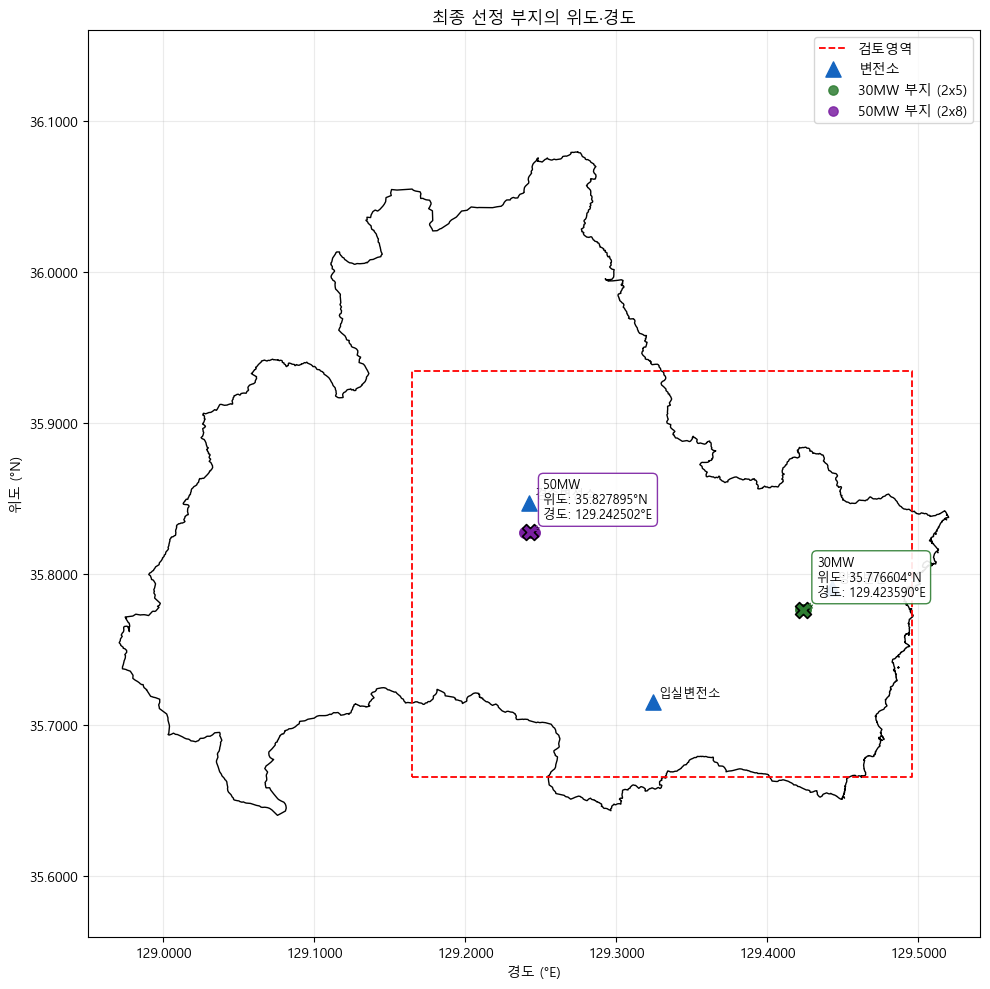

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))

if "ring" in boundary.columns:
    for _, ring in boundary.groupby("ring"):
        ax.plot(
            ring["lon"],
            ring["lat"],
            color="black",
            linewidth=1.0,
        )
else:
    ax.plot(
        boundary["lon"],
        boundary["lat"],
        color="black",
        linewidth=1.0,
        label="경주시 경계",
    )

lon_min, lon_max = grid["lon"].min(), grid["lon"].max()
lat_min, lat_max = grid["lat"].min(), grid["lat"].max()
ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    linestyle="--",
    linewidth=1.3,
    color="red",
    label="검토영역",
)

ax.scatter(
    substations["lon"],
    substations["lat"],
    marker="^",
    s=120,
    color="#1565c0",
    label="변전소",
    zorder=5,
)
for sub in substations.itertuples():
    ax.annotate(
        sub.name,
        (sub.lon, sub.lat),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=9,
    )

from matplotlib.ticker import FormatStrFormatter

colors = {30: "#2e7d32", 50: "#7b1fa2"}

for site in final_sites.itertuples():
    cells = grid_indexed.loc[list(site.cells)].reset_index()

    # 선택된 부지의 격자 표시
    ax.scatter(
        cells["lon"],
        cells["lat"],
        s=45,
        color=colors[site.size_class],
        alpha=0.85,
        label=f"{site.size_class}MW 부지 ({site.shape})",
        zorder=6,
    )

    # 부지 중심점 표시
    ax.scatter(
        site.center_lon,
        site.center_lat,
        marker="X",
        s=130,
        color=colors[site.size_class],
        edgecolor="black",
        linewidth=1.2,
        zorder=7,
    )

    # 부지명과 위도·경도 표시
    coordinate_text = (
        f"{site.size_class}MW\n"
        f"위도: {site.center_lat:.6f}°N\n"
        f"경도: {site.center_lon:.6f}°E"
    )

    ax.annotate(
        coordinate_text,
        xy=(site.center_lon, site.center_lat),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=9,
        bbox={
            "boxstyle": "round,pad=0.4",
            "facecolor": "white",
            "edgecolor": colors[site.size_class],
            "alpha": 0.9,
        },
        arrowprops={
            "arrowstyle": "->",
            "color": colors[site.size_class],
        },
        zorder=8,
    )

ax.set_title("최종 선정 부지의 위도·경도")
ax.set_xlabel("경도 (°E)")
ax.set_ylabel("위도 (°N)")

# 축의 위도·경도 값을 소수점 넷째 자리까지 표시
ax.xaxis.set_major_formatter(FormatStrFormatter("%.4f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))

ax.axis("equal")
ax.grid(alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "final_selected_sites_coordinates.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## 8. ESS 예산 증설 시뮬레이션

Stage 1이 가능한 각 규모 조합의 최소 필요 ESS 비용을 예산제약 없이 한 번 계산한다. 이후 ESS 예산 100·120·130·150·200억원에서 가능한 최대용량과 최적 조합을 비교한다.


In [10]:
required_ess_rows = []

for (n30, n50), stage1 in stage1_solutions.items():
    if (n30, n50) in base_solutions:
        stage2 = base_solutions[(n30, n50)]["stage2"]
    else:
        stage2 = solve_ess_sizing(
            stage1["selected"],
            wind_profile,
            ess_budget=None,
            verbose=False,
        )
    if stage2 is None:
        continue

    construction_cost = (
        BUILD_COST[30] * n30
        + BUILD_COST[50] * n50
    )
    total_capacity = 30 * n30 + 50 * n50
    required_ess_rows.append(
        {
            "n30": n30,
            "n50": n50,
            "scenario": (
                f"30MW {n30}개 + 50MW {n50}개"
            ),
            "total_capacity_mw": total_capacity,
            "construction_cost_eok": construction_cost,
            "transmission_cost_eok": stage1[
                "transmission_cost_eok"
            ],
            "required_ess_mwh": stage2["total_ess_mwh"],
            "required_ess_cost_eok": stage2["ess_cost_eok"],
            "total_project_cost_eok": (
                construction_cost
                + stage1["transmission_cost_eok"]
                + stage2["ess_cost_eok"]
            ),
        }
    )

required_ess = pd.DataFrame(required_ess_rows)
budget_rows = []

for budget in [100, 120, 130, 150, 200]:
    feasible = required_ess.loc[
        required_ess["required_ess_cost_eok"] <= budget + 1e-9
    ].sort_values(
        ["total_capacity_mw", "total_project_cost_eok"],
        ascending=[False, True],
    )

    if feasible.empty:
        budget_rows.append(
            {
                "ess_budget_eok": budget,
                "status": "실행가능 조합 없음",
            }
        )
        continue

    best = feasible.iloc[0]
    budget_rows.append(
        {
            "ess_budget_eok": budget,
            "status": "정상",
            "max_capacity_mw": best["total_capacity_mw"],
            "best_scenario": best["scenario"],
            "required_ess_mwh": best["required_ess_mwh"],
            "required_ess_cost_eok": best[
                "required_ess_cost_eok"
            ],
            "transmission_cost_eok": best[
                "transmission_cost_eok"
            ],
        }
    )

budget_simulation = pd.DataFrame(budget_rows)
display(budget_simulation.round(4))

required_ess.to_csv(
    OUTPUT_DIR / "required_ess_by_configuration.csv",
    index=False,
    encoding="utf-8-sig",
)
budget_simulation.to_csv(
    OUTPUT_DIR / "ess_budget_simulation.csv",
    index=False,
    encoding="utf-8-sig",
)


,ess_budget_eok,status,max_capacity_mw,best_scenario,required_ess_mwh,required_ess_cost_eok,transmission_cost_eok
0,100,정상,80,30MW 1개 + 50MW 1개,40.2460,80.4919,45.3458
1,120,정상,100,30MW 0개 + 50MW 2개,55.7401,111.4802,45.3532
2,130,정상,100,30MW 0개 + 50MW 2개,55.7401,111.4802,45.3532
3,150,정상,100,30MW 0개 + 50MW 2개,55.7401,111.4802,45.3532
4,200,정상,110,30MW 2개 + 50MW 1개,76.8582,153.7163,68.0779


## 정리

최종 추천안은 기본예산에서 실행 가능한 조합 중 총용량을 우선 최대화하고, 동일 용량이면 총사업비가 작은 조합이다. 인구는 실제 인원수가 아닌 후보지 평균 상대 밀도지표로 반영되며, 경사등급과 송전선 비용 조건을 만족하는 대안 중 저밀도 부지를 선택하는 기준으로 사용된다.
